# ESM fine-tuning — фон: филогения (ESM) vs функциональные отклики

Две матрицы 409×409 в **одном** семейном порядке (кластеризация по mean-ESM, как в `esm_screening`):

1. **ESM cosine** — «филогенетическое» сходство рецепторов (то, что кодирует ESM).
2. **Response similarity** — сходство по тому, как рецепторы **реально откликаются** на молекулы: если два рецептора связывают один и тот же набор молекул (и НЕ связывают один и тот же) — они близки.

**Вопрос:** видны ли в матрице *откликов* те же семейные кластеры, что задаёт филогения? Т.е. группируются ли рецепторы похоже по своему **поведению**, а не по последовательности.

**Аккуратность метрики откликов.** Сравниваем только по молекулам, протестированным на *обоих*; согласие корректируем на случайность (**Cohen's κ**, чтобы «оба почти всё не связывают» не читалось как ложное сходство); пары с малой статистикой **маскируем** (не штрафуем рецепторы за неизмеренность), а оценки с малой поддержкой сжимаем к нейтральному (shrinkage).

In [49]:
import sys, warnings, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from orbind import dataset as D

DATA = ROOT / 'data'
FIG  = ROOT / 'notebooks' / 'protein_embeddings' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
print('repo root:', ROOT)

repo root: c:\Users\User\Desktop\SberWork\orbind


In [50]:
# --- ESM mean эмбеддинги + семьи + фиксированный порядок (как в esm_screening) ---
# curated-npz после реорга удалён -> берём FULL (780) и фильтруем по curated-рецепторам (409).
EMB_all = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_full.npz')
pairs   = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
cur     = set(pairs['receptor'].unique())
keys    = [k for k in EMB_all if k in cur]         # curated рецепторы, детерминированный порядок
EMB     = {k: EMB_all[k] for k in keys}
E_mean  = np.stack([EMB[k] for k in keys]).astype(np.float64)
print(f'ESM mean (curated из full): {E_mean.shape[0]} рецепторов x {E_mean.shape[1]}')

bw_ref  = pd.read_csv(DATA / 'processed' / 'bw_ref_used_curated.csv')
seq2ref = bw_ref.set_index('receptor')['ref_entry'].to_dict()
def _family(seq):
    slug = seq2ref.get(seq, 'unk_human').replace('_human', '')
    m = re.match(r'^(or?\d+)', slug)
    return m.group(1).upper() if m else slug.upper()
families = [_family(k) for k in keys]
fam_set  = sorted(set(families))

def _cnorm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

E_norm = _cnorm(E_mean)
ordered_idx = []
for fam in fam_set:
    idx = [i for i, f in enumerate(families) if f == fam]
    if len(idx) <= 3:
        ordered_idx.extend(idx)
    else:
        Z = linkage(E_norm[idx], method='average', metric='cosine')
        ordered_idx.extend([idx[j] for j in leaves_list(Z)])
ORDER = np.array(ordered_idx)
N = len(ORDER)

fam_ord = [families[i] for i in ORDER]
bounds, fam_labels, prev = [], [], None
for i, f in enumerate(fam_ord):
    if f != prev:
        bounds.append(i); fam_labels.append((i, f)); prev = f
mids = [(bounds[j] + (bounds[j+1] if j+1 < len(bounds) else N)) / 2 for j in range(len(bounds))]
SEP_LW = 1.8

def _decorate(ax):
    for b in bounds[1:]:
        ax.axhline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
        ax.axvline(b - 0.5, color='cyan', lw=SEP_LW, alpha=0.85)
    for mid, (_, f) in zip(mids, fam_labels):
        ax.text(mid, N + 1.5, f, ha='center', va='top', fontsize=4.5, rotation=90, color='black')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

print(f'порядок: {N} рецепторов, {len(fam_set)} семей')

ESM mean (curated из full): 409 рецепторов x 1280
порядок: 409 рецепторов, 17 семей


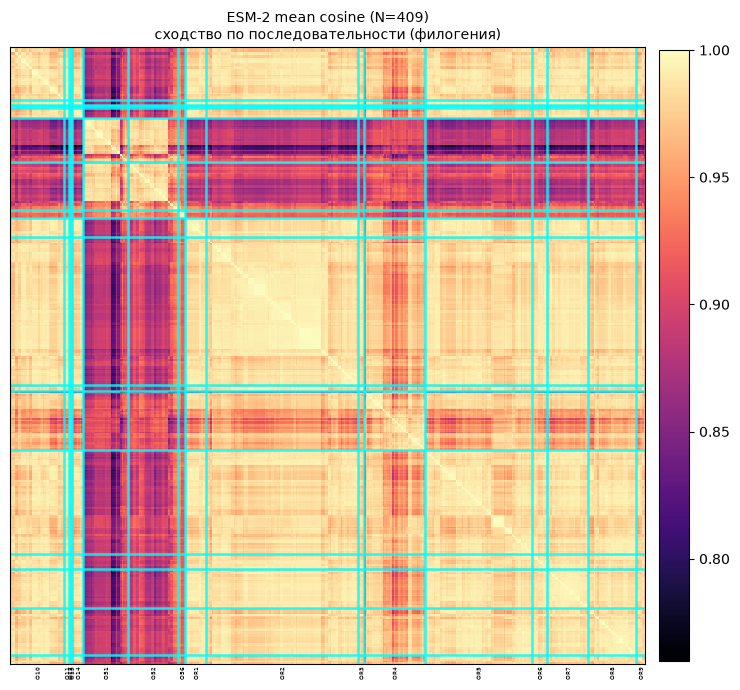

In [51]:
# --- Матрица 1: ESM cosine (филогенетическое сходство) ---
S_esm = (E_norm @ E_norm.T)[np.ix_(ORDER, ORDER)]
off = S_esm[~np.eye(N, dtype=bool)]

fig, ax = plt.subplots(figsize=(7.5, 7))
im = ax.imshow(S_esm, cmap='magma', vmin=off.min(), vmax=1.0, interpolation='nearest', aspect='auto')
_decorate(ax)
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
ax.set_title(f'ESM-2 mean cosine (N={N})\nсходство по последовательности (филогения)', fontsize=10)
fig.tight_layout(); fig.savefig(FIG / 'ft_esm_cosine.png', dpi=140, bbox_inches='tight'); plt.show()

In [52]:
# --- Матрица 2: сходство по откликам (Cohen's kappa, аккуратно) ---
# Для пары рецепторов сравниваем метки ТОЛЬКО по молекулам, протестированным на обоих.
# Согласие корректируем на случайность (kappa): "оба почти всё НЕ связывают" -> kappa ~ 0,
# а не ложные ~1. Пары с малой поддержкой маскируем; оценки сжимаем к 0 (shrinkage).
K_MIN = 8     # минимум общих протестированных молекул, иначе маскируем (нет статистики)
N0    = 12    # сила shrinkage к нейтральному (0) для пар с малой поддержкой

pairs = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
mols  = sorted(pairs['inchikey'].unique())
midx  = {m: j for j, m in enumerate(mols)}
kidx  = {k: i for i, k in enumerate(keys)}
T = np.zeros((N, len(mols)), dtype=np.float64)   # протестировано (1/0)
P = np.zeros_like(T)                             # положительно = связывает (1/0)
for r in pairs.itertuples(index=False):
    i = kidx.get(r.receptor)
    if i is None:
        continue
    j = midx[r.inchikey]
    T[i, j] = 1.0
    if r.label == 1:
        P[i, j] = 1.0

# всё через матричные произведения по общим молекулам (быстро, 409x488)
n     = T @ T.T                    # число общих протестированных молекул на пару
n11   = P @ P.T                    # оба положительны
a_pos = P @ T.T                    # a+ и b протестирован (позитивы a внутри общих)
b_pos = T @ P.T                    # b+ и a протестирован
n00   = n - a_pos - b_pos + n11    # оба отрицательны (внутри общих)

with np.errstate(divide='ignore', invalid='ignore'):
    po = (n11 + n00) / n                       # наблюдаемое согласие
    pa = a_pos / n
    pb = b_pos / n
    pe = pa * pb + (1 - pa) * (1 - pb)         # согласие по случайности
    kappa = (po - pe) / (1 - pe)               # Cohen's kappa

bad = (n < K_MIN) | (~np.isfinite(kappa)) | ((1 - pe) < 1e-9)  # мало данных / нет вариации
kappa[bad] = np.nan
kappa = kappa * (n / (n + N0))                 # shrinkage к 0 по поддержке
np.fill_diagonal(kappa, 1.0)

# статистика покрытия
offdiag = ~np.eye(N, dtype=bool)
frac_masked = np.isnan(kappa[offdiag]).mean()
med_shared  = np.median(n[offdiag])
print(f'K_MIN={K_MIN}, shrink N0={N0}')
print(f'медиана общих молекул на пару: {med_shared:.0f}')
print(f'замаскировано пар (мало статистики / нет вариации): {frac_masked:.1%}')

fam_arr = np.array(families)
same = (fam_arr[:, None] == fam_arr[None, :])
val  = offdiag & np.isfinite(kappa)
print(f'средняя kappa  within-family : {np.nanmean(kappa[val & same]):.3f}')
print(f'средняя kappa  between-family: {np.nanmean(kappa[val & ~same]):.3f}')

K_MIN=8, shrink N0=12
медиана общих молекул на пару: 44
замаскировано пар (мало статистики / нет вариации): 24.5%
средняя kappa  within-family : 0.091
средняя kappa  between-family: 0.074


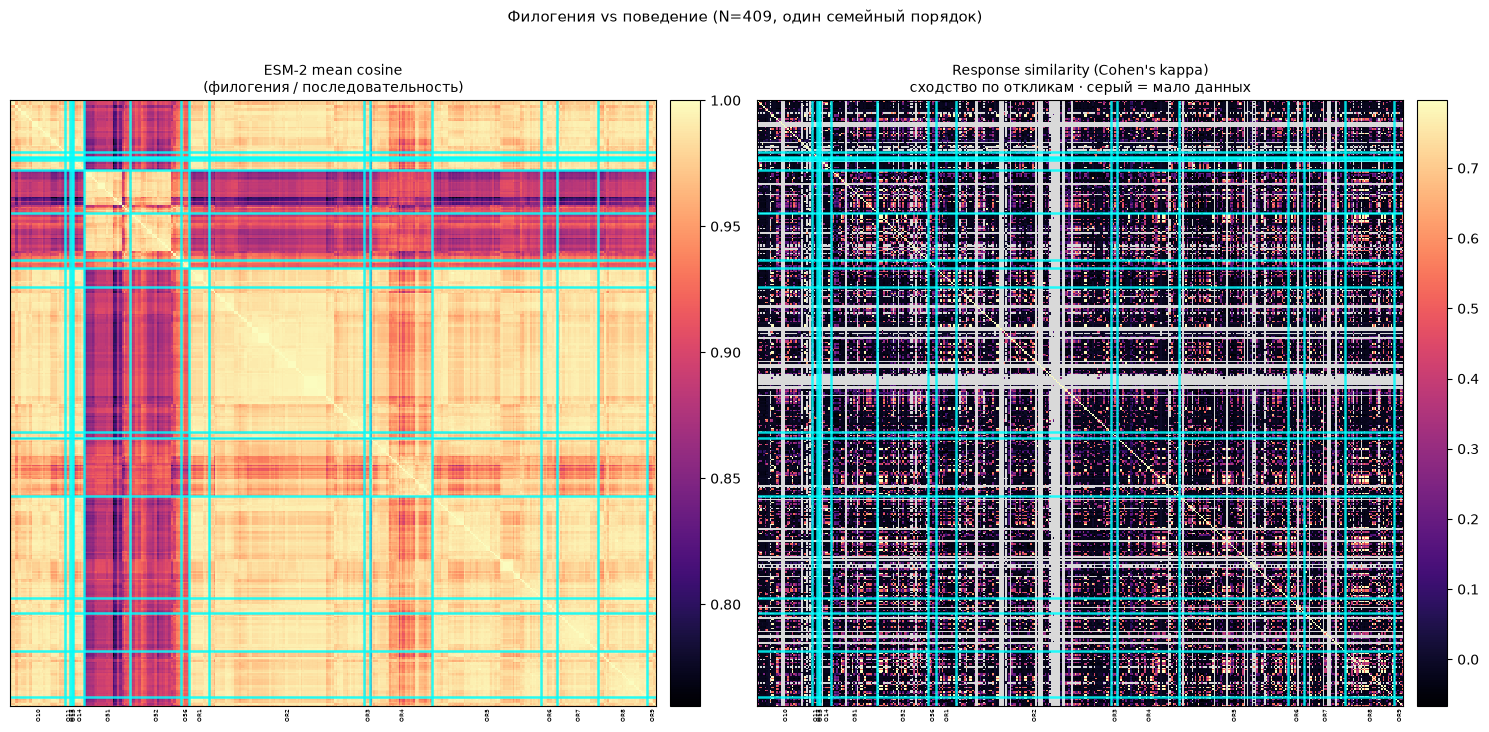

In [33]:
# --- Сравнение матриц в одном семейном порядке ---
Kord   = kappa[np.ix_(ORDER, ORDER)]
cmap_k = plt.get_cmap('magma').copy(); cmap_k.set_bad('#d9d9d9')   # серый = нет данных
kv     = Kord[np.isfinite(Kord) & ~np.eye(N, dtype=bool)]

fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
im0 = axes[0].imshow(S_esm, cmap='magma', vmin=off.min(), vmax=1.0,
                     interpolation='nearest', aspect='auto')
_decorate(axes[0]); fig.colorbar(im0, ax=axes[0], fraction=0.045, pad=0.02)
axes[0].set_title('ESM-2 mean cosine\n(филогения / последовательность)', fontsize=10)

im1 = axes[1].imshow(Kord, cmap=cmap_k,
                     vmin=np.nanpercentile(kv, 2), vmax=np.nanpercentile(kv, 98),
                     interpolation='nearest', aspect='auto')
_decorate(axes[1]); fig.colorbar(im1, ax=axes[1], fraction=0.045, pad=0.02)
axes[1].set_title("Response similarity (Cohen's kappa)\nсходство по откликам · серый = мало данных", fontsize=10)

fig.suptitle(f'Филогения vs поведение (N={N}, один семейный порядок)', fontsize=11, y=1.01)
fig.tight_layout(); fig.savefig(FIG / 'ft_esm_vs_response.png', dpi=140, bbox_inches='tight'); plt.show()

In [ ]:
# --- ESM cosine vs отклик (kappa): числа БЕЗ усреднения по «тёмному» фону ---
# Глобальный Spearman ~0 обманчив: он усредняет тьму ДАЛЁКИХ пар (низкий cosine, kappa у пола).
# Читаем связь по-человечески: как средний отклик-kappa зависит от близости по ESM (по бинам),
# и отдельно — у ближайших соседей против фона.
S     = E_norm @ E_norm.T
iu    = np.triu_indices(N, k=1)
esm_v, kap_v, same_v = S[iu], kappa[iu], same[iu]
ok    = np.isfinite(kap_v)
esm_v, kap_v, same_v = esm_v[ok], kap_v[ok], same_v[ok]
n_all = len(kap_v)

# 1) бины по близости ESM (доля ближайших пар) -> средний отклик в каждом
qs    = [0.0, 0.5, 0.8, 0.95, 0.99, 1.0]
edges = np.quantile(esm_v, qs)
print(f'{n_all} валидных пар рецепторов. Средний отклик-kappa ПО БИНАМ близости ESM:')
print(f'{"квантиль":>11} {"диапазон cosine":>20} {"n пар":>7} {"mean kappa":>11} {"median":>8}')
mids, means, sems = [], [], []
for i in range(len(qs) - 1):
    lo, hi = edges[i], edges[i + 1]
    m = (esm_v >= lo) & (esm_v <= hi) if i == len(qs) - 2 else (esm_v >= lo) & (esm_v < hi)
    k = kap_v[m]
    print(f'{qs[i]:.2f}-{qs[i+1]:.2f}   [{lo:.3f}, {hi:.3f}]  {int(m.sum()):7d}  {k.mean():+11.3f}  {np.median(k):+8.3f}')
    mids.append((qs[i] + qs[i + 1]) / 2); means.append(k.mean()); sems.append(k.std() / np.sqrt(max(len(k), 1)))

# 2) ближайшие ESM-соседи против фона (числа, а не облако)
Sd = S.copy(); np.fill_diagonal(Sd, -np.inf)
def _knn_kappa(k):
    vals = []
    for i in range(N):
        nb = np.argsort(-Sd[i])[:k]
        kk = kappa[i, nb]; kk = kk[np.isfinite(kk)]
        if len(kk):
            vals.append(kk.mean())
    return float(np.mean(vals))
k1, k5 = _knn_kappa(1), _knn_kappa(5)
bg = float(kap_v.mean())
wf, bf = float(kap_v[same_v].mean()), float(kap_v[~same_v].mean())
print(f'\nБлижайший ESM-сосед (k=1):  mean kappa {k1:+.3f}')
print(f'5 ближайших   (k=5):        mean kappa {k5:+.3f}')
print(f'within-family:              mean kappa {wf:+.3f}')
print(f'between-family:             mean kappa {bf:+.3f}')
print(f'ФОН (все валидные пары):    mean kappa {bg:+.3f}')

# доля пар с НАСТОЯЩИМ согласием (kappa > порога): ближайший сосед vs фон
nn1 = np.array([kappa[i, int(np.argmax(Sd[i]))] for i in range(N)])
nn1 = nn1[np.isfinite(nn1)]
print(f'\nДоля пар с реальным согласием (kappa > порога):   ближайший ESM-сосед  vs  фон (все пары)')
for thr in (0.2, 0.3, 0.4):
    print(f'  kappa > {thr:.1f}:   сосед {100*np.mean(nn1 > thr):5.1f}%      фон {100*np.mean(kap_v > thr):5.1f}%')
print(f'  (у ближайшего соседа медиана kappa {np.median(nn1):+.3f} -> «типичный» паралог всё равно почти не согласуется)')

# 3) корреляция: глобальная (обманчивая) vs только среди близких (top-20% cosine)
rho_all, _ = spearmanr(esm_v, kap_v)
hi_mask    = esm_v >= np.quantile(esm_v, 0.8)
rho_hi, _  = spearmanr(esm_v[hi_mask], kap_v[hi_mask])
print(f'\nSpearman rho:  глобально {rho_all:+.3f}   |   только среди 20% ближайших {rho_hi:+.3f}')
print('Вывод: связь есть, но ЛОКАЛЬНАЯ — глобальное усреднение по далёким парам её прячет.')

# график: слева отклик по бинам близости, справа соседи vs фон (без scatter-облака)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].errorbar(mids, means, yerr=sems, marker='o', lw=1.6, capsize=3, color='#e0863c')
ax[0].axhline(bg, color='gray', ls='--', lw=0.9, label=f'фон {bg:+.3f}')
ax[0].set_xlabel('квантиль близости по ESM cosine (правее = ближе)')
ax[0].set_ylabel('средний отклик-kappa')
ax[0].set_title('Отклик растёт с близостью по ESM'); ax[0].legend(fontsize=8)

names = ['сосед\nk=1', 'k=5', 'within\nfam', 'between\nfam', 'фон\n(все)']
vals  = [k1, k5, wf, bf, bg]
cols  = ['#c0392b', '#e0863c', '#e05c5c', '#6a9ccc', '#999999']
ax[1].bar(names, vals, color=cols)
ax[1].axhline(bg, color='gray', ls='--', lw=0.9)
ax[1].set_ylabel('средний отклик-kappa'); ax[1].set_title('Ближе по ESM -> сильнее совпадение откликов')
fig.tight_layout(); fig.savefig(FIG / 'ft_esm_vs_response_binned.png', dpi=140, bbox_inches='tight'); plt.show()


## Как читать

- **Слева** — ESM cosine: должны быть яркие блоки по диагонали (семьи похожи по последовательности).
- **Справа** — κ по откликам: если те же диагональные блоки видны → рецепторы, близкие филогенетически, ведут себя (связывают одоранты) тоже похоже. Если блоков нет / картина «размыта» → поведение НЕ следует за филогенией (перекликается с нашим выводом о насыщенном таргете и узкой настройке OR).
- Серые клетки справа = пар слишком мало общих молекул, чтобы судить (честно не оцениваем).
- **Scatter / ρ**: положительная, но, скорее всего, слабая связь ESM↔отклики; within-family κ должна быть чуть выше between-family — но насколько, и есть ли вообще сигнал сверх шума, покажут числа.

---
# Учим свои протеиновые эмбеддинги под задачу (не ESM, не филогения)

Гипотеза-возражение к предыдущей части: ESM кодирует **последовательность**, а поведение за ней почти не следует (ρ≈0). Тогда попробуем **не доверять** ни ESM, ни филогении и выучить представление рецепторов **прямо под предсказание связывания**, стартуя с чистой идентичности (one-hot). Ожидаемо переобучится (трансдуктив, идентичность видна насквозь) — но интересно, во что сгруппируются рецепторы, когда их двигает **только** задача.

Данные: **LORAX fold 1, transductive** (все узлы известны; держим только рёбра). Молекулы — ChemBERTa-77M (384-d, по SMILES).

1. **A.** one-hot рецептора ‖ ChemBERTa → XGBoost (референс-число «чистой идентичности»).
2. **B.** one-hot → глубокий MLP → 100-d эмбеддинг; молекула → MLP; поверх обоих ещё MLP; всё учим на edge prediction (BCE), 600 эпох, лог train/val loss, сохраняем last и best-by-val.
3. **C.** выученные 100-d эмбеддинги рецепторов в 3D (PCA), раскраска по семьям.
4. **D.** XGBoost по выученным эмбеддингам ‖ ChemBERTa (стандартная схема).


In [35]:
# === A. one-hot рецептора + ChemBERTa -> XGBoost (LORAX fold 1, transductive) ===
import pickle
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

LFOLD = 1
lbase = DATA / 'external' / 'lorax_m2or' / f'rand_split_{LFOLD}'
tr = pd.read_csv(lbase / 'train_df.csv')
va = pd.read_csv(lbase / 'val_df.csv')
te = pd.read_csv(lbase / 'test_df.csv')
with open(DATA / 'embeddings' / 'molecules' / 'chemberta_77m_lorax.pkl', 'rb') as f:
    CHEM = {k: np.asarray(v, np.float32) for k, v in pickle.load(f).items()}

# идентичности по ВСЕМ белкам/молекулам фолда (transductive: все узлы известны)
prot_ids = sorted(set(tr['Protein sequence']) | set(va['Protein sequence']) | set(te['Protein sequence']))
mol_ids  = sorted(set(tr['SMILES']) | set(va['SMILES']) | set(te['SMILES']))
pidx = {p: i for i, p in enumerate(prot_ids)}
NP_  = len(prot_ids)
print(f'fold {LFOLD}: {NP_} белков, {len(mol_ids)} молекул | train {len(tr)}  val {len(va)}  test {len(te)}')
print(f'  test-белков не встречалось в train: {len(set(te["Protein sequence"]) - set(tr["Protein sequence"]))}')

def _onehot(seqs):
    X = np.zeros((len(seqs), NP_), np.float32)
    X[np.arange(len(seqs)), [pidx[s] for s in seqs]] = 1.0
    return X
def _mol(smiles):
    return np.stack([CHEM[s] for s in smiles]).astype(np.float32)
def _Xoh(df):
    return np.concatenate([_mol(df['SMILES']), _onehot(df['Protein sequence'])], axis=1)

ytr = tr['output'].to_numpy(); yte = te['output'].to_numpy()
clf = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                    n_jobs=-1, tree_method='hist', random_state=0)
clf.fit(_Xoh(tr), ytr)
p_oh = clf.predict_proba(_Xoh(te))[:, 1]
AUC_OH = roc_auc_score(yte, p_oh)
print(f'[A: one-hot ‖ ChemBERTa -> XGBoost]  test AUROC={AUC_OH:.3f}  AUPRC={average_precision_score(yte, p_oh):.3f}')


fold 1: 1237 белков, 596 молекул | train 40826  val 4172  test 1565
  test-белков не встречалось в train: 39
[A: one-hot ‖ ChemBERTa -> XGBoost]  test AUROC=0.806  AUPRC=0.631


ep  0  train 1.3055  val 1.2485   (best val 1.2485 @ 0)
ep  1  train 1.2863  val 1.2084   (best val 1.2084 @ 1)
ep  2  train 1.2268  val 1.1083   (best val 1.1083 @ 2)
ep  3  train 1.1378  val 1.0141   (best val 1.0141 @ 3)
ep  4  train 1.0618  val 0.9957   (best val 0.9957 @ 4)
ep  5  train 1.0152  val 0.9275   (best val 0.9275 @ 5)
ep  6  train 0.9651  val 0.9043   (best val 0.9043 @ 6)
ep  7  train 0.9205  val 0.8761   (best val 0.8761 @ 7)
ep  8  train 0.8934  val 0.8637   (best val 0.8637 @ 8)
ep  9  train 0.8550  val 0.8360   (best val 0.8360 @ 9)
ep 10  train 0.8260  val 0.8246   (best val 0.8246 @ 10)
ep 11  train 0.8114  val 0.8135   (best val 0.8135 @ 11)
ep 12  train 0.7846  val 0.8030   (best val 0.8030 @ 12)
ep 13  train 0.7801  val 0.8168   (best val 0.8030 @ 12)
ep 14  train 0.7640  val 0.7903   (best val 0.7903 @ 14)
ep 15  train 0.7299  val 0.7869   (best val 0.7869 @ 15)
ep 16  train 0.7202  val 0.7997   (best val 0.7869 @ 15)
ep 17  train 0.7248  val 0.7886   (best v

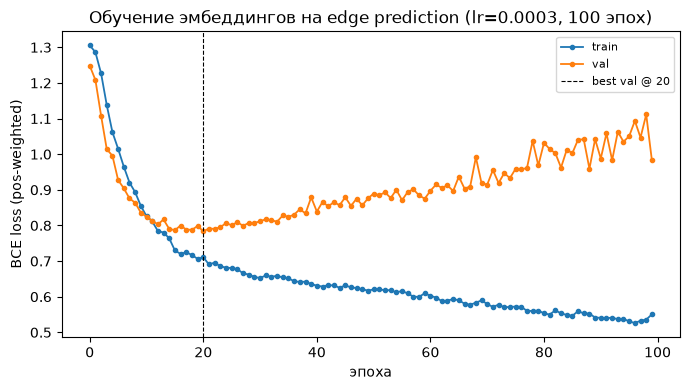

In [36]:
# === B. учим эмбеддинги на edge prediction (one-hot -> MLP -> 100-d) ===
import copy, time
import torch
import torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
EMB, EPOCHS, BATCH, LR = 100, 100, 4096, 3e-4      # мало эпох + пониженный lr
midx = {m: i for i, m in enumerate(mol_ids)}
MOLMAT = torch.tensor(np.stack([CHEM[m] for m in mol_ids]), dtype=torch.float32, device=DEV)  # (Nmol,384)

def _tens(df):
    return (torch.tensor([pidx[s] for s in df['Protein sequence']], dtype=torch.long, device=DEV),
            torch.tensor([midx[s] for s in df['SMILES']], dtype=torch.long, device=DEV),
            torch.tensor(df['output'].to_numpy(), dtype=torch.float32, device=DEV))
trP, trM, trY = _tens(tr); vaP, vaM, vaY = _tens(va); teP, teM, teY = _tens(te)

# Рецептор входит как one-hot идентичности. Первый линейный слой по one-hot ==
# lookup строки веса, поэтому его считаем через nn.Embedding (та же функция, без
# материализации 1237-мерного вектора). Дальше идёт запрошенный глубокий MLP -> 100.
class EdgeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.p_in  = nn.Embedding(NP_, 256)                # == Linear(NP_,256,bias=False) на one-hot
        self.prot  = nn.Sequential(                        # глубокий MLP -> 100
            nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, EMB))
        self.mol = nn.Sequential(                          # ChemBERTa -> MLP -> 100
            nn.Linear(384, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, EMB))
        self.head = nn.Sequential(                         # поверх обоих ещё MLP -> logit
            nn.Linear(2 * EMB, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1))
    def prot_emb(self, pi_):
        return self.prot(self.p_in(pi_))
    def forward(self, pi_, mi_):
        zp = self.prot_emb(pi_); zm = self.mol(MOLMAT[mi_])
        return self.head(torch.cat([zp, zm], 1)).squeeze(1)

model = EdgeNet().to(DEV)
pos_w = torch.tensor([(trY == 0).sum() / (trY == 1).sum().clamp(min=1)], device=DEV)
crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

@torch.no_grad()
def _full_logits(P, M):
    model.eval()
    out = torch.empty(len(P), device=DEV)
    for s in range(0, len(P), 8192):
        out[s:s + 8192] = model(P[s:s + 8192], M[s:s + 8192])
    return out

hist = {'train': [], 'val': []}
best_val, best_state, best_ep = float('inf'), None, -1
n = len(trY); t0 = time.time()
for ep in range(EPOCHS):
    model.train()
    perm = torch.randperm(n, device=DEV)
    run = 0.0
    for s in range(0, n, BATCH):
        b = perm[s:s + BATCH]
        opt.zero_grad()
        loss = crit(model(trP[b], trM[b]), trY[b])
        loss.backward(); opt.step()
        run += loss.item() * len(b)
    tl = run / n
    vl = crit(_full_logits(vaP, vaM), vaY).item()
    hist['train'].append(tl); hist['val'].append(vl)
    if vl < best_val:
        best_val, best_ep = vl, ep
        best_state = copy.deepcopy(model.state_dict())
    print(f'ep {ep:2d}  train {tl:.4f}  val {vl:.4f}   (best val {best_val:.4f} @ {best_ep})')

last_state = copy.deepcopy(model.state_dict())
CKPT = FIG.parent / 'checkpoints'; CKPT.mkdir(exist_ok=True)
torch.save(best_state, CKPT / f'ft_edgenet_fold{LFOLD}_best.pt')
torch.save(last_state, CKPT / f'ft_edgenet_fold{LFOLD}_last.pt')
print(f'\ndone in {time.time()-t0:.0f}s (lr={LR}, {EPOCHS} эпох)  |  best val {best_val:.4f} @ epoch {best_ep}  |  '
      f'сохранены best/last -> {CKPT}')

@torch.no_grad()
def _test_auc(state):
    model.load_state_dict(state)
    return roc_auc_score(teY.cpu().numpy(), _full_logits(teP, teM).cpu().numpy())
print(f'test AUROC:  best-by-val={_test_auc(best_state):.3f}   last={_test_auc(last_state):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(EPOCHS), hist['train'], 'o-', ms=3, label='train', lw=1.3)
ax.plot(range(EPOCHS), hist['val'], 'o-', ms=3, label='val', lw=1.3)
ax.axvline(best_ep, color='k', ls='--', lw=0.8, label=f'best val @ {best_ep}')
ax.set_xlabel('эпоха'); ax.set_ylabel('BCE loss (pos-weighted)')
ax.set_title(f'Обучение эмбеддингов на edge prediction (lr={LR}, {EPOCHS} эпох)'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / 'ft_learned_train_curve.png', dpi=140, bbox_inches='tight'); plt.show()


эмбеддинги рецепторов: best (1237, 100), last (1237, 100)


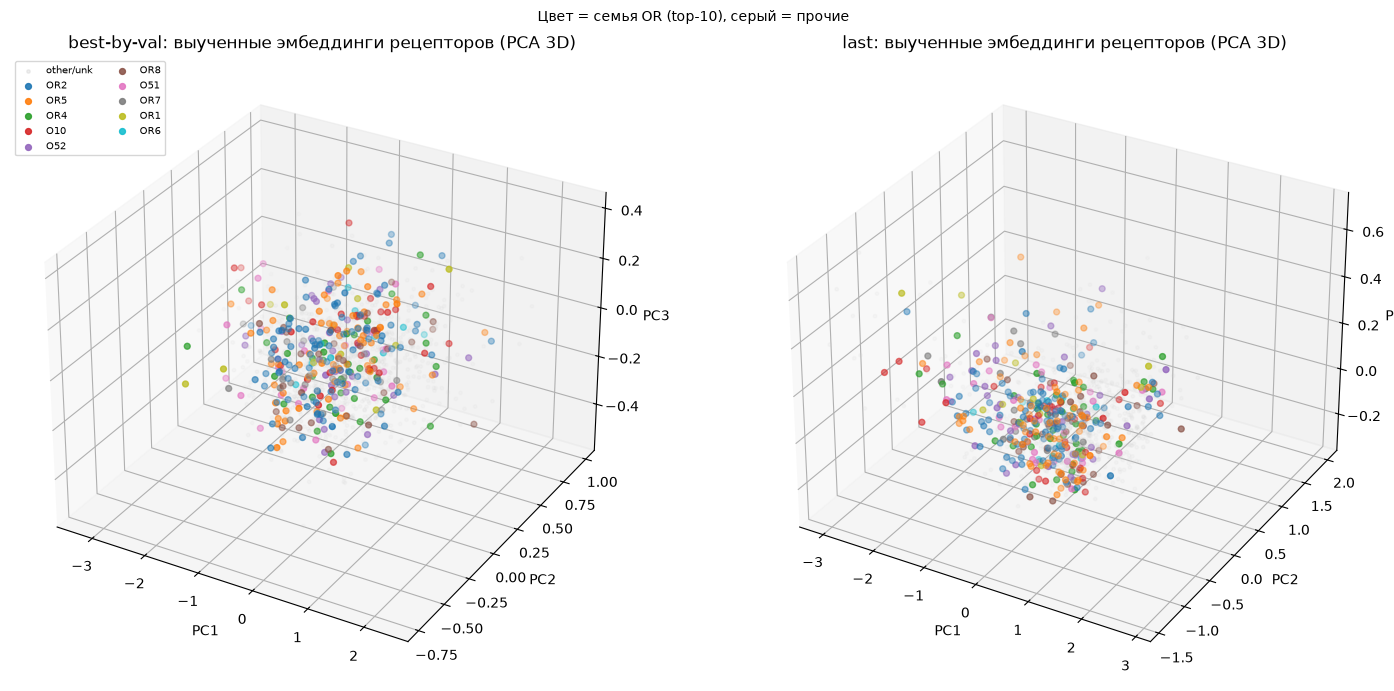

In [37]:
# === C. выученные эмбеддинги рецепторов в 3D — best-by-val И last ===
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

@torch.no_grad()
def _emb_all(state):
    model.load_state_dict(state); model.eval()
    return model.prot_emb(torch.arange(NP_, device=DEV)).cpu().numpy()   # (NP_,100)
Zp_best = _emb_all(best_state)
Zp_last = _emb_all(last_state)
print(f'эмбеддинги рецепторов: best {Zp_best.shape}, last {Zp_last.shape}')

# семья по последовательности (там, где известна из curated); иначе "other"
def _fam_seq(seq):
    if seq not in seq2ref:
        return 'other'
    slug = seq2ref[seq].replace('_human', '')
    mm = re.match(r'^(or?\d+)', slug)
    return mm.group(1).upper() if mm else 'other'
fam_l = np.array([_fam_seq(s) for s in prot_ids])
top = [f for f, _ in sorted(((f, (fam_l == f).sum()) for f in set(fam_l) if f != 'other'),
                            key=lambda x: -x[1])[:10]]
cmap = plt.get_cmap('tab10')
col_of = {f: cmap(i) for i, f in enumerate(top)}
rest = ~np.isin(fam_l, top)

fig = plt.figure(figsize=(15, 7))
for k, (name, Z) in enumerate([('best-by-val', Zp_best), ('last', Zp_last)]):
    P3 = PCA(n_components=3, random_state=0).fit_transform(Z)
    ax = fig.add_subplot(1, 2, k + 1, projection='3d')
    ax.scatter(P3[rest, 0], P3[rest, 1], P3[rest, 2], s=6, c='#cfcfcf', alpha=0.35, label='other/unk')
    for f in top:
        m = fam_l == f
        ax.scatter(P3[m, 0], P3[m, 1], P3[m, 2], s=18, color=col_of[f], alpha=0.9, label=f)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title(f'{name}: выученные эмбеддинги рецепторов (PCA 3D)')
    if k == 0:
        ax.legend(fontsize=7, loc='upper left', ncol=2)
fig.suptitle('Цвет = семья OR (top-10), серый = прочие', fontsize=10, y=0.98)
fig.tight_layout(); fig.savefig(FIG / 'ft_learned_emb_3d.png', dpi=140, bbox_inches='tight'); plt.show()


In [38]:
# === D. XGBoost по ВЫУЧЕННЫМ эмбеддингам ‖ ChemBERTa — best И last (стандартная схема) ===
def _run_xgb(Z, tag):
    Zt = {p: Z[i] for i, p in enumerate(prot_ids)}
    def _X(df):
        Xp = np.stack([Zt[s] for s in df['Protein sequence']]).astype(np.float32)
        return np.concatenate([_mol(df['SMILES']), Xp], axis=1)
    c = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                      subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                      n_jobs=-1, tree_method='hist', random_state=0)
    c.fit(_X(tr), ytr)
    p = c.predict_proba(_X(te))[:, 1]
    auc, ap = roc_auc_score(yte, p), average_precision_score(yte, p)
    print(f'[D {tag:11s} ‖ ChemBERTa -> XGBoost]  test AUROC={auc:.3f}  AUPRC={ap:.3f}')
    return auc

AUC_BEST = _run_xgb(Zp_best, 'best-by-val')
AUC_LAST = _run_xgb(Zp_last, 'last')
print(f'[A one-hot     ‖ ChemBERTa -> XGBoost]  test AUROC={AUC_OH:.3f}')
print('\nПрим.: transductive one-hot видит идентичность рецептора насквозь -> сильный, но не переносимый '
      'референс. Выученные эмбеддинги — сжатые (100-d) представления той же идентичности, подвинутые задачей; '
      'best vs last показывает, насколько ранняя остановка по val меняет и число (D), и геометрию кластеров (C).')


[D best-by-val ‖ ChemBERTa -> XGBoost]  test AUROC=0.822  AUPRC=0.693
[D last        ‖ ChemBERTa -> XGBoost]  test AUROC=0.807  AUPRC=0.676
[A one-hot     ‖ ChemBERTa -> XGBoost]  test AUROC=0.806

Прим.: transductive one-hot видит идентичность рецептора насквозь -> сильный, но не переносимый референс. Выученные эмбеддинги — сжатые (100-d) представления той же идентичности, подвинутые задачей; best vs last показывает, насколько ранняя остановка по val меняет и число (D), и геометрию кластеров (C).


In [39]:
# === E. РЕФЕРЕНС: ChemBERTa ‖ ESM-1b mean -> XGBoost (тот же фолд, те же условия) ===
# "Филогенетический" референс: рецептор = готовый ESM-1b 650M mean (последовательность),
# без обучения под задачу. Молекула и XGBoost — как в A/D.
ESM_LORAX = D.load_npz_dict(DATA / 'external' / 'lorax_m2or' / 'esm1b_650m_mean_lorax.npz')
ESM_LORAX = {k: np.asarray(v, np.float32) for k, v in ESM_LORAX.items()}
assert all(s in ESM_LORAX for s in prot_ids), 'нет ESM для части белков фолда'

def _Xesm(df):
    Xp = np.stack([ESM_LORAX[s] for s in df['Protein sequence']]).astype(np.float32)
    return np.concatenate([_mol(df['SMILES']), Xp], axis=1)

clf_esm = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
                        n_jobs=-1, tree_method='hist', random_state=0)
clf_esm.fit(_Xesm(tr), ytr)
p_esm = clf_esm.predict_proba(_Xesm(te))[:, 1]
AUC_ESM = roc_auc_score(yte, p_esm)
print(f'[E ESM-1b mean  ‖ ChemBERTa -> XGBoost]  test AUROC={AUC_ESM:.3f}  AUPRC={average_precision_score(yte, p_esm):.3f}')

print('\n--- сводка на LORAX fold 1, transductive ---')
print(f'  A  one-hot          : {AUC_OH:.3f}')
print(f'  D  learned best-val : {AUC_BEST:.3f}')
print(f'  D  learned last     : {AUC_LAST:.3f}')
print(f'  E  ESM-1b mean      : {AUC_ESM:.3f}')
print('ESM здесь — референс «филогения без обучения»: если выученные эмбеддинги (D) и one-hot (A) '
      'его не превосходят, значит на трансдуктиве всё решает идентичность рецептора, а не то, ESM это или своё.')


[E ESM-1b mean  ‖ ChemBERTa -> XGBoost]  test AUROC=0.891  AUPRC=0.769

--- сводка на LORAX fold 1, transductive ---
  A  one-hot          : 0.806
  D  learned best-val : 0.822
  D  learned last     : 0.807
  E  ESM-1b mean      : 0.891
ESM здесь — референс «филогения без обучения»: если выученные эмбеддинги (D) и one-hot (A) его не превосходят, значит на трансдуктиве всё решает идентичность рецептора, а не то, ESM это или своё.


---
## ESM → MLP: дообучаем ESM под задачу

Референс E показал, что **frozen ESM ‖ ChemBERTa → XGBoost = 0.891** — заметно выше one-hot/learned (~0.81–0.83). Значит на трансдуктиве ESM несёт больше, чем идентичность. Вопрос: если вместо one-hot подать в тот же interaction-net **ESM-вектор** (1280-d) → MLP → 100, станет ли обучаемое представление лучше frozen-ESM, или голова только испортит готовый признак?

Всё остальное — как в B (та же голова, `EPOCHS=20`, `lr=3e-4`, best/last, график лосса), меняется только вход протеиновой башни: one-hot → ESM.

ep  0  train 1.3050  val 1.2494   (best 1.2494 @ 0)
ep  1  train 1.2881  val 1.2144   (best 1.2144 @ 1)
ep  2  train 1.2435  val 1.1581   (best 1.1581 @ 2)
ep  3  train 1.2015  val 1.1179   (best 1.1179 @ 3)
ep  4  train 1.1736  val 1.0981   (best 1.0981 @ 4)
ep  5  train 1.1488  val 1.1032   (best 1.0981 @ 4)
ep  6  train 1.1333  val 1.0661   (best 1.0661 @ 6)
ep  7  train 1.1191  val 1.0599   (best 1.0599 @ 7)
ep  8  train 1.0868  val 1.0525   (best 1.0525 @ 8)
ep  9  train 1.0767  val 1.0094   (best 1.0094 @ 9)
ep 10  train 1.0478  val 0.9945   (best 0.9945 @ 10)
ep 11  train 1.0313  val 0.9745   (best 0.9745 @ 11)
ep 12  train 1.0184  val 0.9630   (best 0.9630 @ 12)
ep 13  train 0.9981  val 0.9461   (best 0.9461 @ 13)
ep 14  train 0.9935  val 0.9357   (best 0.9357 @ 14)
ep 15  train 0.9831  val 0.9507   (best 0.9357 @ 14)
ep 16  train 0.9667  val 0.9238   (best 0.9238 @ 16)
ep 17  train 0.9550  val 0.9046   (best 0.9046 @ 17)
ep 18  train 0.9348  val 0.8796   (best 0.8796 @ 18)
ep 

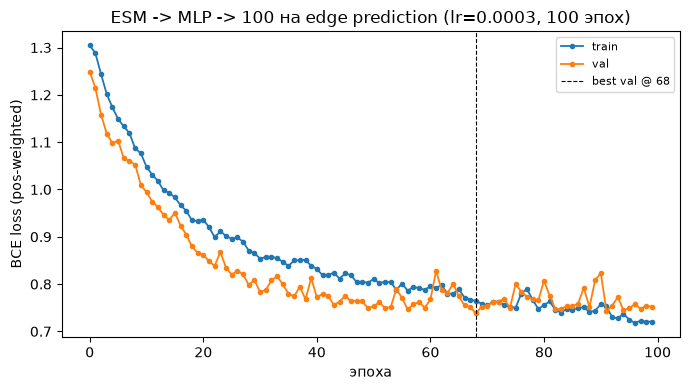

In [40]:
# === F. ESM -> MLP -> 100, обучение на edge prediction (те же условия, что B) ===
PROT_ESM = torch.tensor(np.stack([ESM_LORAX[s] for s in prot_ids]), dtype=torch.float32, device=DEV)  # (NP_,1280)

class EdgeNetESM(nn.Module):
    # то же, что EdgeNet, но протеиновая башня принимает ESM-вектор, а не one-hot
    def __init__(self):
        super().__init__()
        self.prot = nn.Sequential(
            nn.Linear(1280, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, EMB))
        self.mol = nn.Sequential(
            nn.Linear(384, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, EMB))
        self.head = nn.Sequential(
            nn.Linear(2 * EMB, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1))
    def prot_emb(self, pi_):
        return self.prot(PROT_ESM[pi_])
    def forward(self, pi_, mi_):
        zp = self.prot_emb(pi_); zm = self.mol(MOLMAT[mi_])
        return self.head(torch.cat([zp, zm], 1)).squeeze(1)

def train_edgenet(net, epochs=EPOCHS, lr=LR, tag=''):
    net = net.to(DEV)
    crit_ = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt_  = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-5)
    @torch.no_grad()
    def _fl(P, M):
        net.eval(); out = torch.empty(len(P), device=DEV)
        for s in range(0, len(P), 8192):
            out[s:s + 8192] = net(P[s:s + 8192], M[s:s + 8192])
        return out
    h = {'train': [], 'val': []}
    bv, bstate, bep = float('inf'), None, -1
    n = len(trY); t0 = time.time()
    for ep in range(epochs):
        net.train(); perm = torch.randperm(n, device=DEV); run = 0.0
        for s in range(0, n, BATCH):
            b = perm[s:s + BATCH]
            opt_.zero_grad(); loss = crit_(net(trP[b], trM[b]), trY[b])
            loss.backward(); opt_.step(); run += loss.item() * len(b)
        tl = run / n; vl = crit_(_fl(vaP, vaM), vaY).item()
        h['train'].append(tl); h['val'].append(vl)
        if vl < bv:
            bv, bep = vl, ep; bstate = copy.deepcopy(net.state_dict())
        print(f'ep {ep:2d}  train {tl:.4f}  val {vl:.4f}   (best {bv:.4f} @ {bep})')
    lstate = copy.deepcopy(net.state_dict())
    net.load_state_dict(bstate); ab = roc_auc_score(teY.cpu().numpy(), _fl(teP, teM).cpu().numpy())
    net.load_state_dict(lstate); al = roc_auc_score(teY.cpu().numpy(), _fl(teP, teM).cpu().numpy())
    print(f'\n{tag} done in {time.time()-t0:.0f}s  |  best val {bv:.4f} @ {bep}  |  '
          f'test AUROC best={ab:.3f}  last={al:.3f}')
    return net, h, bstate, lstate, bep

torch.manual_seed(0); np.random.seed(0)
model_e, hist_e, best_e, last_e, bep_e = train_edgenet(EdgeNetESM(), tag='[F ESM->MLP]')
torch.save(best_e, CKPT / f'ft_esmnet_fold{LFOLD}_best.pt')
torch.save(last_e, CKPT / f'ft_esmnet_fold{LFOLD}_last.pt')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(EPOCHS), hist_e['train'], 'o-', ms=3, label='train', lw=1.3)
ax.plot(range(EPOCHS), hist_e['val'], 'o-', ms=3, label='val', lw=1.3)
ax.axvline(bep_e, color='k', ls='--', lw=0.8, label=f'best val @ {bep_e}')
ax.set_xlabel('эпоха'); ax.set_ylabel('BCE loss (pos-weighted)')
ax.set_title(f'ESM -> MLP -> 100 на edge prediction (lr={LR}, {EPOCHS} эпох)'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / 'ft_esm_mlp_train_curve.png', dpi=140, bbox_inches='tight'); plt.show()


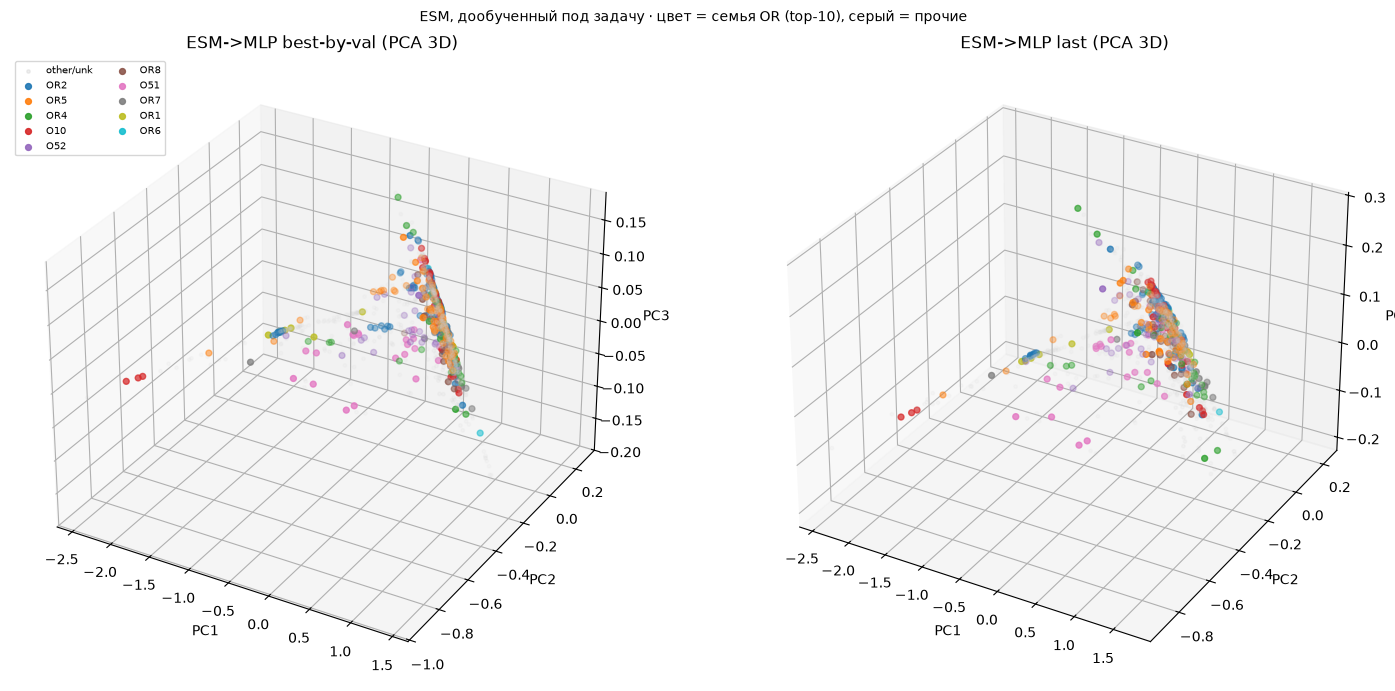

In [41]:
# === G. выученные ESM->MLP эмбеддинги в 3D (best и last) ===
@torch.no_grad()
def _emb_all_e(state):
    model_e.load_state_dict(state); model_e.eval()
    return model_e.prot_emb(torch.arange(NP_, device=DEV)).cpu().numpy()
Ze_best = _emb_all_e(best_e); Ze_last = _emb_all_e(last_e)

fig = plt.figure(figsize=(15, 7))
for k, (name, Z) in enumerate([('ESM->MLP best-by-val', Ze_best), ('ESM->MLP last', Ze_last)]):
    P3 = PCA(n_components=3, random_state=0).fit_transform(Z)
    ax = fig.add_subplot(1, 2, k + 1, projection='3d')
    ax.scatter(P3[rest, 0], P3[rest, 1], P3[rest, 2], s=6, c='#cfcfcf', alpha=0.35, label='other/unk')
    for f in top:
        m = fam_l == f
        ax.scatter(P3[m, 0], P3[m, 1], P3[m, 2], s=18, color=col_of[f], alpha=0.9, label=f)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title(f'{name} (PCA 3D)')
    if k == 0:
        ax.legend(fontsize=7, loc='upper left', ncol=2)
fig.suptitle('ESM, дообученный под задачу · цвет = семья OR (top-10), серый = прочие', fontsize=10, y=0.98)
fig.tight_layout(); fig.savefig(FIG / 'ft_esm_mlp_emb_3d.png', dpi=140, bbox_inches='tight'); plt.show()


In [42]:
# === H. XGBoost по ESM->MLP эмбеддингам (best и last) + общая сводка ===
AUC_E_BEST = _run_xgb(Ze_best, 'ESM-MLP best')
AUC_E_LAST = _run_xgb(Ze_last, 'ESM-MLP last')

print('\n==== ИТОГ: LORAX fold 1, transductive (ChemBERTa на молекулах, XGBoost одинаков) ====')
print(f'  A  one-hot                 : {AUC_OH:.3f}')
print(f'  D  learned (one-hot->MLP) b: {AUC_BEST:.3f}   last {AUC_LAST:.3f}')
print(f'  E  frozen ESM-1b mean      : {AUC_ESM:.3f}')
print(f'  H  ESM->MLP (дообуч.)     b: {AUC_E_BEST:.3f}   last {AUC_E_LAST:.3f}')
print('\nЧитается так: если H <= E — голова/сжатие только теряет информацию готового ESM (на трансдуктиве '
      'дообучать нечего, признак уже насыщен); если H > E — обучение под задачу что-то добавляет. '
      'Настоящую проверку это получит на переносимых сплитах (group_molecule), где идентичность не спасает.')


[D ESM-MLP best ‖ ChemBERTa -> XGBoost]  test AUROC=0.875  AUPRC=0.753
[D ESM-MLP last ‖ ChemBERTa -> XGBoost]  test AUROC=0.871  AUPRC=0.739

==== ИТОГ: LORAX fold 1, transductive (ChemBERTa на молекулах, XGBoost одинаков) ====
  A  one-hot                 : 0.806
  D  learned (one-hot->MLP) b: 0.822   last 0.807
  E  frozen ESM-1b mean      : 0.891
  H  ESM->MLP (дообуч.)     b: 0.875   last 0.871

Читается так: если H <= E — голова/сжатие только теряет информацию готового ESM (на трансдуктиве дообучать нечего, признак уже насыщен); если H > E — обучение под задачу что-то добавляет. Настоящую проверку это получит на переносимых сплитах (group_molecule), где идентичность не спасает.


---
## Честные контроли: почему H < E — это сжатие/арена, а не «обучение вредит»

Разрыв `E (frozen ESM→XGB, 0.891)` vs `H (learned-100→XGB, 0.875)` смешивает три вещи: сжатие 1280→100, «обучаемая проекция vs линейная», и ридер. Изолируем по одной, **ридер везде = XGBoost** (мы выяснили, что слабая нейронная голова — это и есть узкое место, а не белковые признаки):

- **I. PCA-100(ESM) → XGBoost** — линейное (необучаемое) сжатие 1280→100. Эталон «сжали, но не учили».
- **J. дообученная башня 100-d → XGBoost** vs I и vs `E (frozen ESM 1280 → XGBoost)`. Тот же бустинг-ридер во всех плечах. Дообучение помогает ⇔ `trained-100 > PCA-100` (одинаковая размерность 100-d). Ячейка самодостаточна: пересчитывает эмбеддинги из свежих `best_e/last_e`, так что после прогона F с бо́льшим числом эпох достаточно перезапустить только её.

In [43]:
# === I. КОНТРОЛЬ сжатия: PCA-100(ESM) -> XGBoost (тот же ридер, что E/H) ===
E_esm_np = np.stack([ESM_LORAX[s] for s in prot_ids]).astype(np.float32)   # (NP_,1280), порядок prot_ids
Zpca = PCA(n_components=100, random_state=0).fit_transform(E_esm_np)
AUC_PCA = _run_xgb(Zpca, 'PCA-100 ESM')

print('\n--- ось «сжатие», ридер = XGBoost ---')
print(f'  E  full ESM 1280   : {AUC_ESM:.3f}')
print(f'  I  PCA-100 ESM     : {AUC_PCA:.3f}')
print(f'  H  learned-100 ESM : {AUC_E_BEST:.3f} (best) / {AUC_E_LAST:.3f} (last)')
print('Если I ~ H -> обучаемое 100-d не лучше линейной проекции; провал E->H это цена сжатия 1280->100, '
      'а не «обучение вредит».')


[D PCA-100 ESM ‖ ChemBERTa -> XGBoost]  test AUROC=0.886  AUPRC=0.766

--- ось «сжатие», ридер = XGBoost ---
  E  full ESM 1280   : 0.891
  I  PCA-100 ESM     : 0.886
  H  learned-100 ESM : 0.875 (best) / 0.871 (last)
Если I ~ H -> обучаемое 100-d не лучше линейной проекции; провал E->H это цена сжатия 1280->100, а не «обучение вредит».


In [44]:
# === J. дообученная башня vs PCA — РИДЕР = XGBoost в обоих плечах (не MLP-голова) ===
# Раньше J читал frozen нейронной головой (слабый ридер занижал frozen). Меняем ридер на бустинг:
# честный тест «помогает ли дообучение белковой башни» при одинаковой размерности 100-d.
# Самодостаточно: берёт свежие best_e/last_e -> после F с бо'льшим числом эпох перезапусти только J.
Ze_best_j = _emb_all_e(best_e)      # дообученная башня 100-d (best-by-val)
Ze_last_j = _emb_all_e(last_e)      # дообученная башня 100-d (last)

AUC_TR_BEST = _run_xgb(Ze_best_j, 'trained-100 best')
AUC_TR_LAST = _run_xgb(Ze_last_j, 'trained-100 last')

print('\n--- «помогает ли дообучение башни», РИДЕР = XGBoost везде ---')
print(f'  E  frozen ESM 1280   -> XGB : {AUC_ESM:.3f}')
print(f'  I  PCA-100(ESM)      -> XGB : {AUC_PCA:.3f}   (untrained линейное 100-d)')
print(f'  J  trained tower 100 -> XGB : {AUC_TR_BEST:.3f} best / {AUC_TR_LAST:.3f} last')
print('Дообучение окупается ТОЛЬКО если trained-100 > PCA-100 (честное сравнение при равной '
      'размерности). Отставание от frozen-1280 (E) включает ещё и неизбежную цену сжатия 1280->100. '
      'Если и с бо́льшим числом эпох trained-100 <= PCA-100 -> на трансдуктиве дообучать белковую '
      'башню нечего, потолок держит дерево на сыром ESM.')


[D trained-100 best ‖ ChemBERTa -> XGBoost]  test AUROC=0.875  AUPRC=0.753
[D trained-100 last ‖ ChemBERTa -> XGBoost]  test AUROC=0.871  AUPRC=0.739

--- «помогает ли дообучение башни», РИДЕР = XGBoost везде ---
  E  frozen ESM 1280   -> XGB : 0.891
  I  PCA-100(ESM)      -> XGB : 0.886   (untrained линейное 100-d)
  J  trained tower 100 -> XGB : 0.875 best / 0.871 last
Дообучение окупается ТОЛЬКО если trained-100 > PCA-100 (честное сравнение при равной размерности). Отставание от frozen-1280 (E) включает ещё и неизбежную цену сжатия 1280->100. Если и с бо́льшим числом эпох trained-100 <= PCA-100 -> на трансдуктиве дообучать белковую башню нечего, потолок держит дерево на сыром ESM.


---
## Механизм: чем хорош ESM на трансдуктиве?

Парадокс: ESM почти не коррелирует с поведением (ρ≈0.003, within/between-family κ 0.091/0.074 — крошечные), но при этом это **лучший** белковый признак (0.891 vs one-hot 0.806). Гипотеза: на трансдуктиве ESM работает не как предсказатель поведения, а как **плотный гладкий ключ** рецептора, чья ценность = (1) покрытие невиденных рецепторов и (2) partial pooling малоданных. Четыре зонда проверяют это.

- **K1.** случайный плотный ключ vs ESM — филогения или просто плотность?
- **K2.** seen/unseen + поддержка — где именно ESM обгоняет one-hot?
- **K3.** kNN(ESM-сосед) transfer — есть ли локальная структура, скрытая за глобальным ρ≈0?
- **K4.** что дерево реально использует — ESM vs молекула, и сколько ESM-измерений.

In [45]:
# === K1. Контроль: случайный плотный ключ (плотность без филогении) ===
rng = np.random.default_rng(0)
Z_rand = rng.standard_normal((NP_, 1280)).astype(np.float32)   # фикс. случайный вектор НА рецептор
AUC_RAND = _run_xgb(Z_rand, 'random-dense')

print('\n--- плотность ключа vs филогения (ридер = XGBoost, молекула = ChemBERTa) ---')
print(f'  one-hot   (sparse identity)   : {AUC_OH:.3f}')
print(f'  random-dense 1280 (no phylo)  : {AUC_RAND:.3f}')
print(f'  ESM-1b 1280 (dense + phylo)   : {AUC_ESM:.3f}')
print('random-dense ~ ESM  -> помогает просто плотный ключ, филогения ни при чём.')
print('ESM  >  random-dense -> работает именно структура сходства ESM (её проверяем в K2/K3).')


[D random-dense ‖ ChemBERTa -> XGBoost]  test AUROC=0.841  AUPRC=0.683

--- плотность ключа vs филогения (ридер = XGBoost, молекула = ChemBERTa) ---
  one-hot   (sparse identity)   : 0.806
  random-dense 1280 (no phylo)  : 0.841
  ESM-1b 1280 (dense + phylo)   : 0.891
random-dense ~ ESM  -> помогает просто плотный ключ, филогения ни при чём.
ESM  >  random-dense -> работает именно структура сходства ESM (её проверяем в K2/K3).


AUROC на подмножествах теста (one-hot vs ESM, те же обученные модели A/E):
  seen рецепторы             n=1524 pos=329  one-hot=0.820  ESM=0.894  Δ=+0.075
  unseen рецепторы           n=  41 pos= 19  one-hot=0.502  ESM=0.551  Δ=+0.049

seen, по числу train-пар рецептора:
  support       1-39  n= 381  one-hot=0.756  ESM=0.850  Δ=+0.093
  support      40-44  n= 402  one-hot=0.884  ESM=0.912  Δ=+0.028
  support      45-95  n= 394  one-hot=0.784  ESM=0.873  Δ=+0.089
  support     96-268  n= 347  one-hot=0.849  ESM=0.929  Δ=+0.080


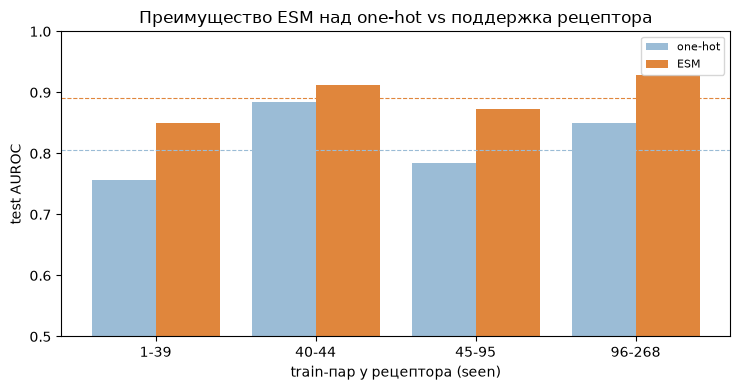


Ожидание: на seen one-hot~ESM; на unseen ESM>>one-hot; Δ тает с ростом поддержки (пулинг нужен там, где своих данных мало).


In [46]:
# === K2. Где живёт преимущество ESM: seen/unseen рецепторы + поддержка ===
train_seqs = set(tr['Protein sequence'])
cnt = tr['Protein sequence'].value_counts().to_dict()
te_seq  = te['Protein sequence'].to_numpy()
seen    = np.array([s in train_seqs for s in te_seq])
support = np.array([cnt.get(s, 0) for s in te_seq])

def _pair(mask, tag):
    n = int(mask.sum())
    if n == 0:
        print(f'  {tag:26s} нет пар'); return
    if yte[mask].min() == yte[mask].max():
        print(f'  {tag:26s} n={n:4d}  один класс -> AUROC не определён'); return
    a_oh  = roc_auc_score(yte[mask], p_oh[mask])
    a_esm = roc_auc_score(yte[mask], p_esm[mask])
    print(f'  {tag:26s} n={n:4d} pos={int(yte[mask].sum()):3d}  one-hot={a_oh:.3f}  ESM={a_esm:.3f}  Δ={a_esm-a_oh:+.3f}')

print('AUROC на подмножествах теста (one-hot vs ESM, те же обученные модели A/E):')
_pair(seen,  'seen рецепторы')
_pair(~seen, 'unseen рецепторы')

# стратификация seen по числу train-пар рецептора
df = pd.DataFrame({'sup': support[seen], 'y': yte[seen], 'oh': p_oh[seen], 'esm': p_esm[seen]})
df['bin'] = pd.qcut(df['sup'], 4, duplicates='drop')
rows = []
for b, g in df.groupby('bin', observed=True):
    if g['y'].nunique() < 2:
        continue
    rows.append((f'{int(g.sup.min())}-{int(g.sup.max())}', roc_auc_score(g.y, g.oh),
                 roc_auc_score(g.y, g.esm), len(g)))
print('\nseen, по числу train-пар рецептора:')
for lab, a_oh, a_esm, ng in rows:
    print(f'  support {lab:>10s}  n={ng:4d}  one-hot={a_oh:.3f}  ESM={a_esm:.3f}  Δ={a_esm-a_oh:+.3f}')

if rows:
    labs = [r[0] for r in rows]; x = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(x - 0.2, [r[1] for r in rows], 0.4, label='one-hot', color='#9bbcd6')
    ax.bar(x + 0.2, [r[2] for r in rows], 0.4, label='ESM', color='#e0863c')
    ax.axhline(AUC_OH, color='#9bbcd6', ls='--', lw=0.8); ax.axhline(AUC_ESM, color='#e0863c', ls='--', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylim(0.5, 1.0)
    ax.set_xlabel('train-пар у рецептора (seen)'); ax.set_ylabel('test AUROC')
    ax.set_title('Преимущество ESM над one-hot vs поддержка рецептора'); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FIG / 'ft_probe_seen_support.png', dpi=140, bbox_inches='tight'); plt.show()
print('\nОжидание: на seen one-hot~ESM; на unseen ESM>>one-hot; Δ тает с ростом поддержки '
      '(пулинг нужен там, где своих данных мало).')


In [47]:
# === K3. Локальная kNN-предсказуемость: ESM-сосед vs случайный ===
from collections import defaultdict
En   = E_esm_np / (np.linalg.norm(E_esm_np, axis=1, keepdims=True) + 1e-9)
Ccos = En @ En.T                                   # (NP_,NP_) косинус ESM
tr_by_mol = defaultdict(list)                      # SMILES -> [(rec_idx, label)]
for s, sm, y in zip(tr['Protein sequence'], tr['SMILES'], tr['output']):
    tr_by_mol[sm].append((pidx[s], float(y)))

KNN = 5; rng = np.random.default_rng(0)
ys, nn_s, rd_s = [], [], []
for s, sm, y in zip(te['Protein sequence'], te['SMILES'], te['output']):
    ri = pidx[s]
    cand = [(pi, lab) for pi, lab in tr_by_mol.get(sm, []) if pi != ri]
    if len(cand) < 2:
        continue
    idxs = np.array([pi for pi, _ in cand]); labs = np.array([lab for _, lab in cand])
    k = min(KNN, len(cand))
    near = np.argsort(-Ccos[ri, idxs])[:k]                     # k ближайших по ESM
    nn_s.append(labs[near].mean())
    rd_s.append(labs[rng.choice(len(cand), size=k, replace=False)].mean())  # k случайных
    ys.append(y)
ys = np.array(ys)
print(f'{len(ys)} test-пар с >=2 co-testing train-рецепторами (k={KNN})')
print(f'  kNN(ESM-ближайшие) transfer AUROC : {roc_auc_score(ys, nn_s):.3f}')
print(f'  kNN(случайные)     transfer AUROC : {roc_auc_score(ys, rd_s):.3f}')
print('ESM-сосед > случайного -> локальная структура ЕСТЬ, её просто смывает глобальный ρ (тьма '
      'далёких пар у пола). Это и есть «полезная филогения», которой пользуется дерево.')


1542 test-пар с >=2 co-testing train-рецепторами (k=5)
  kNN(ESM-ближайшие) transfer AUROC : 0.748
  kNN(случайные)     transfer AUROC : 0.607
ESM-сосед > случайного -> локальная структура ЕСТЬ, её просто смывает глобальный ρ (тьма далёких пар у пола). Это и есть «полезная филогения», которой пользуется дерево.


base AUROC 0.891  (перестановка блока рвёт его связь с меткой -> падение = вклад блока)
  permute MOL block (384) : ΔAUROC 0.160 ± 0.011
  permute ESM block (1280): ΔAUROC 0.338 ± 0.013

ESM-блок: 1274 из 1280 измерений с ненулевой важностью; 341 несут 50% важности, 989 — 90%.


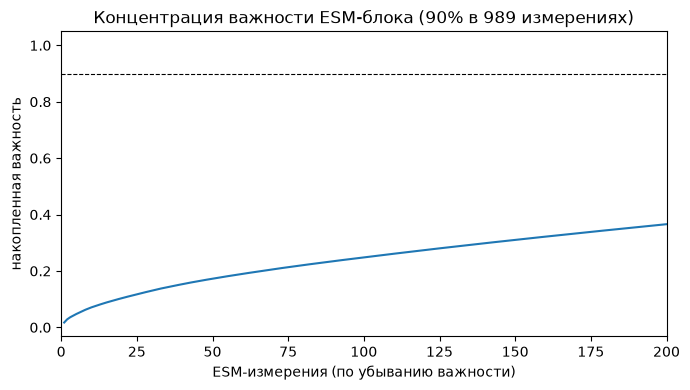

Мало измерений (десятки) -> ключ почти «идентичность» (few effective dim, как и находили раньше). Много распределённых -> дерево читает структурную геометрию ESM.


In [48]:
# === K4. Что дерево реально использует: block-permutation + концентрация по ESM-dim ===
Xte_e = _Xesm(te)                                  # [mol 384 | ESM 1280]
base  = roc_auc_score(yte, clf_esm.predict_proba(Xte_e)[:, 1])
rng   = np.random.default_rng(0)

def _perm_drop(sl, reps=5):
    drops = []
    for _ in range(reps):
        Xp = Xte_e.copy()
        Xp[:, sl] = Xte_e[rng.permutation(Xte_e.shape[0])][:, sl]   # рвём связь блока с меткой
        drops.append(base - roc_auc_score(yte, clf_esm.predict_proba(Xp)[:, 1]))
    return float(np.mean(drops)), float(np.std(drops))

d_mol = _perm_drop(slice(0, 384)); d_esm = _perm_drop(slice(384, 384 + 1280))
print(f'base AUROC {base:.3f}  (перестановка блока рвёт его связь с меткой -> падение = вклад блока)')
print(f'  permute MOL block (384) : ΔAUROC {d_mol[0]:.3f} ± {d_mol[1]:.3f}')
print(f'  permute ESM block (1280): ΔAUROC {d_esm[0]:.3f} ± {d_esm[1]:.3f}')

imp = np.asarray(clf_esm.feature_importances_[384:], dtype=float)   # важность (gain) по ESM-dim
order = np.argsort(-imp); cum = np.cumsum(imp[order]) / (imp.sum() + 1e-12)
n50 = int((cum <= 0.5).sum()) + 1; n90 = int((cum <= 0.9).sum()) + 1
nz  = int((imp > 0).sum())
print(f'\nESM-блок: {nz} из 1280 измерений с ненулевой важностью; '
      f'{n50} несут 50% важности, {n90} — 90%.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, lw=1.5)
ax.axhline(0.9, color='k', ls='--', lw=0.8); ax.axvline(n90, color='#e0863c', ls='--', lw=0.8)
ax.set_xlabel('ESM-измерения (по убыванию важности)'); ax.set_ylabel('накопленная важность')
ax.set_title(f'Концентрация важности ESM-блока (90% в {n90} измерениях)')
ax.set_xlim(0, min(200, len(cum)))
fig.tight_layout(); fig.savefig(FIG / 'ft_probe_esm_importance.png', dpi=140, bbox_inches='tight'); plt.show()
print('Мало измерений (десятки) -> ключ почти «идентичность» (few effective dim, как и находили раньше). '
      'Много распределённых -> дерево читает структурную геометрию ESM.')
